# ASSIGNMENT 1: TRIP GENERATION
------------

**Jaime Alejandro Garcia**

**Fall - 2026**

**Class  CME 508 Urban Travel Forecasting**

---------------------------
This assignment corresponds to the first task of the course “CME 508 Urban Travel Forecasting”; it focuses on the study and practical application of trip generation and attraction models within a transportation modeling framework. Additionally, the opportunity will be taken to advance the work using Python, allowing for a comparison with the development carried out in Excel.

---------------
**Objectives of this report**

The assignment examines trip generation using three complementary approaches:

1. Develop and compare household-based and zone-based linear regression models for daily work trips.
2. Develop a household-based linear regression model for daily non-work trips and compare it with the household work-trip model.
3. Develop a cross-classification model for daily non-work trips using household size and vehicle ownership.


## 1. Setup and Imports
-----------
Before addressing the three points outlined in the assignment, the environment for this work will be prepared. This involves configuring the project—which is also available in the public GitHub repository at https://github.com/jaagarciamu/508_CME_Tranportation_plan.git and importing the necessary libraries. These include libraries for numerical processing (such as NumPy), data manipulation (Pandas), visualization (Matplotlib and Seaborn), and statistical analysis and regression (Statsmodels and SciPy). This section also covers loading the dataset to be used.

In [268]:
# report: hide-output
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import math
from matplotlib.legend_handler import HandlerTuple
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from pathlib import Path
from scipy.stats import shapiro
import seaborn as sns
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm
import statsmodels.formula.api as smf

<!-- report: hide-cell -->
### 1.1. Definition of useful functions
-----
This section defines various functions that will be useful during the development of the work but will not be shown in the final version.

In [269]:
# report: hide-cell
def plot_regression_diagnostics(model):

    fig, axes = plt.subplots(
        1, 2,
        figsize=(6.5, 1.7)
    )

    # -----------------------------
    # 1. Residuals vs Fitted
    # -----------------------------
    axes[0].scatter(
        model.fittedvalues,
        model.resid,
        s=14,
        alpha=0.8
    )

    axes[0].axhline(
        y=0,
        linestyle="--",
        linewidth=0.8
    )

    axes[0].set_title(
        "Residuals vs Fitted",
        fontsize=8
    )

    axes[0].set_xlabel(
        "Fitted Values",
        fontsize=7
    )

    axes[0].set_ylabel(
        "Residuals",
        fontsize=7
    )

    axes[0].tick_params(
        axis="both",
        labelsize=6
    )

    axes[0].grid(
        alpha=0.15,
        linewidth=0.4
    )

    # -----------------------------
    # 2. Q-Q Plot
    # -----------------------------
    sm.qqplot(
        model.resid,
        line="45",
        fit=True,
        ax=axes[1],
        marker="o",
        markersize=3
    )

    axes[1].set_title(
        "Q-Q Plot of Residuals",
        fontsize=8
    )

    axes[1].set_xlabel(
        "Theoretical Quantiles",
        fontsize=7
    )

    axes[1].set_ylabel(
        "Sample Quantiles",
        fontsize=7
    )

    axes[1].tick_params(
        axis="both",
        labelsize=6
    )

    axes[1].grid(
        alpha=0.15,
        linewidth=0.4
    )

    # Compact spacing
    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.20,
        top=0.82,
        wspace=0.28
    )

    plt.show()

In [270]:
# report: hide-cell
def plot_correlations(corr_left, corr_right, 
                      title_left="Zones Correlation",
                      title_right="Household Correlation"):

    mask = np.triu(
        np.ones_like(corr_left, dtype=bool)
    )

    fig, axes = plt.subplots(
        1, 2,
        figsize=(18, 8)
    )

    # Left correlation
    sns.heatmap(
        corr_left,
        mask=mask,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 9},
        square=True,
        linewidths=0.5,
        cbar=False,
        ax=axes[0]
    )

    axes[0].set_title(title_left)

    axes[0].tick_params(
        axis="y",
        labelsize=8
    )

    axes[0].tick_params(
        axis="x",
        labelsize=8
    )

    # Right correlation
    sns.heatmap(
        corr_right,
        mask=mask,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 9},
        square=True,
        linewidths=0.5,
        cbar=False,
        yticklabels=False,
        ax=axes[1]
    )

    axes[1].set_title(title_right)

    axes[1].tick_params(
        axis="x",
        labelsize=8
    )

    # Shared colorbar
    sm = ScalarMappable(
        norm=Normalize(vmin=-1, vmax=1),
        cmap="coolwarm"
    )

    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes,
        shrink=0.5
    )

    cbar.set_label(
        "Correlation coefficient",
        fontsize=8
    )

    cbar.ax.tick_params(
        labelsize=7
    )

    plt.show()

In [271]:
# report: hide-cell
def plot_correlation_1(corr, title="Correlation Matrix", figsize=(8, 6)):

    # Match the proportions of one panel in the 18 x 8 comparison figure.
    text_scale = min(figsize[0] / 9, figsize[1] / 8)

    # Mask upper triangle
    mask = np.triu(
        np.ones_like(corr, dtype=bool)
    )

    fig, ax = plt.subplots(
        figsize=figsize
    )

    # Heatmap
    sns.heatmap(
        corr,
        mask=mask,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 9 * text_scale},
        square=True,
        linewidths=0.5 * text_scale,
        cbar=False,
        ax=ax
    )

    # Title
    ax.set_title(
        title,
        fontsize=11.5 * text_scale,
        pad=6 * text_scale
    )

    # Variable names
    ax.tick_params(
        axis="both",
        labelsize=8 * text_scale,
        length=2 * text_scale,
        pad=2 * text_scale
    )

    # Colorbar
    sm = ScalarMappable(
        norm=Normalize(vmin=-1, vmax=1),
        cmap="coolwarm"
    )

    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        shrink=0.5,
        pad=0.04
    )

    cbar.set_label(
        "Correlation coefficient",
        fontsize=8 * text_scale,
        labelpad=4 * text_scale
    )

    cbar.ax.tick_params(
        labelsize=7 * text_scale,
        length=2 * text_scale,
        pad=2 * text_scale
    )

    plt.tight_layout(pad=0.5)
    plt.show()

In [272]:
# report: hide-cell
def show_anova(model):
    anova = anova_lm(model)

    print("\n" + "=" * 78)
    print("ANOVA TABLE")
    print("=" * 78)

    print(
        anova.to_string(
            formatters={
                "df": lambda x: f"{x:.0f}",
                "sum_sq": lambda x: f"{x:.3f}",
                "mean_sq": lambda x: f"{x:.3f}",
                "F": lambda x: f"{x:.3f}",
                "PR(>F)": lambda x: f"{x:.3e}"
            }
        )
    )

    print("=" * 78)

In [273]:
# report: hide-cell
def stepwise_forward(data, y, X_candidates, criterion="aic"):
    
    selected = []
    remaining = list(X_candidates)

    current_score = float("inf")
    best_model = None

    while remaining:
        scores = []

        for candidate in remaining:
            predictors = selected + [candidate]
            formula = f"{y} ~ " + " + ".join(predictors)

            model = smf.ols(formula, data=data).fit()

            score = getattr(model, criterion)

            scores.append(
                (score, candidate, model)
            )

        scores.sort(key=lambda x: x[0])

        best_new_score, best_candidate, best_new_model = scores[0]

        if best_new_score < current_score:
            selected.append(best_candidate)
            remaining.remove(best_candidate)

            current_score = best_new_score
            best_model = best_new_model

            print(
                f"Add {best_candidate:<12} "
                f"{criterion.upper()} = {current_score:.3f}"
            )

        else:
            break

    return best_model, selected

In [274]:
# report: hide-cell
def normal(column):
    statd, p = shapiro(column.dropna())
    result = "Normal" if p > 0.1 else "Not normal"
    return result 

In [275]:
# report: hide-cell
def IQR(column):
    q25, q75 = column.quantile([0.25, 0.75])
    return q75-q25

In [276]:
# report: hide-cell
def range_f(column):
    return column.max() - column.min()

In [277]:
# report: hide-cell
stats_list = [
    range_f, # custom function
    'median',
    'sum','skew','kurt',
    'var', # numpy function
    IQR,   # custom function
    normal
]

In [278]:
# report: hide-cell
def mode_first(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

In [279]:
# report: hide-cell
def compact_pivot(data, row, col, value, min_count=1):

    temp = data[[row, col, value]].dropna().copy()

    # Convert categories back to numeric values
    temp[row] = pd.to_numeric(temp[row].astype(str))
    temp[col] = pd.to_numeric(temp[col].astype(str))

    row_values = sorted(temp[row].unique())
    col_values = sorted(temp[col].unique())

    best = None

    # Try possible upper grouping limits
    for row_cut in row_values:
        for col_cut in col_values:

            test = temp.copy()

            # Everything >= cutoff belongs to the last category
            test["_row_group"] = test[row].clip(upper=row_cut)
            test["_col_group"] = test[col].clip(upper=col_cut)

            # Number of observations in every combination
            counts = test.pivot_table(
                index="_row_group",
                columns="_col_group",
                values=value,
                aggfunc="count"
            )

            expected_rows = sorted(test["_row_group"].unique())
            expected_cols = sorted(test["_col_group"].unique())

            counts = counts.reindex(
                index=expected_rows,
                columns=expected_cols,
                fill_value=0
            )

            # Require every cell to contain at least min_count observations
            if (counts >= min_count).all().all():

                # Prefer the solution that preserves the most categories
                detail = len(expected_rows) * len(expected_cols)

                if best is None or detail > best[0]:
                    best = (
                        detail,
                        row_cut,
                        col_cut,
                        test
                    )

    if best is None:
        raise ValueError(
            "No grouping was found that satisfies the minimum cell count."
        )

    _, row_cut, col_cut, temp = best

    # Final mean table
    pivot = temp.pivot_table(
        index="_row_group",
        columns="_col_group",
        values=value,
        aggfunc="mean"
    )

    # Better labels
    row_labels = {
        x: f"{int(x)} & more" if x == row_cut and row_cut < max(row_values)
        else str(int(x))
        for x in pivot.index
    }

    col_labels = {
        x: f"{int(x)} & more" if x == col_cut and col_cut < max(col_values)
        else str(int(x))
        for x in pivot.columns
    }

    pivot = pivot.rename(
        index=row_labels,
        columns=col_labels
    )

    pivot.index.name = row
    pivot.columns.name = col

    return pivot.round(2), row_cut, col_cut

### 1.2. Data Loading

In this component, data is loaded directly from the data's source location, which is also found in the repository.

In [280]:
# report: hide-cell
current_dir = Path.cwd()

if (current_dir / "pyproject.toml").exists():
    PROJECT_ROOT = current_dir
else:
    PROJECT_ROOT = next(
        parent
        for parent in current_dir.parents
        if (parent / "pyproject.toml").exists()
    )
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"

print(f"Project root: {PROJECT_ROOT}")

Project root: d:\JAIME_ALEJANDRO_GARCIA\01_ACADEMIC\2026_fall\508_Transportation_planning\Transportatio_Planning\508_CME_Tranportation_plan


In [281]:
data_path = RAW_DATA_DIR / "ps1-data.csv"
df = pd.read_csv(data_path)
df.head(5)

,zone,dwtype,npers,nveh,nlic,nftw,nptw,nwah,nstud,nfem,nmale,nchild,n65+,nwork,nnwk,expfac
0,29,2,3,1,3,1,1,0,1,2,1,0,0,2,9,22.11
1,6,2,2,1,2,2,0,0,0,1,1,0,0,3,7,30.35
2,11,2,1,0,0,0,0,0,0,1,0,0,1,0,0,25.53
3,14,2,1,0,1,0,1,0,1,1,0,0,0,0,3,22.11
4,24,2,2,0,0,0,0,0,2,1,1,0,0,0,4,30.35


## 2. Data Inspection and EDA
-------------
This section presents a general analysis of the provided dataset; this includes examining dimensions, missing values, and data types, as well as conducting exploratory data analysis. Additionally, descriptive statistical techniques—including measures of central tendency and dispersion—are applied to gain a better understanding of the data.

In [282]:
# report: hide-code 
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 2,310
Columns: 16


In [283]:
# report: hide-code 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2310 entries, 0 to 2309
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   zone    2310 non-null   int64  
 1   dwtype  2310 non-null   int64  
 2   npers   2310 non-null   int64  
 3   nveh    2310 non-null   int64  
 4   nlic    2310 non-null   int64  
 5   nftw    2310 non-null   int64  
 6   nptw    2310 non-null   int64  
 7   nwah    2310 non-null   int64  
 8   nstud   2310 non-null   int64  
 9   nfem    2310 non-null   int64  
 10  nmale   2310 non-null   int64  
 11  nchild  2310 non-null   int64  
 12  n65+    2310 non-null   int64  
 13  nwork   2310 non-null   int64  
 14  nnwk    2310 non-null   int64  
 15  expfac  2310 non-null   float64
dtypes: float64(1), int64(15)
memory usage: 288.9 KB


In [284]:
# report: hide-code 
categorical_cols = ["zone", "dwtype"]
df[categorical_cols] = df[categorical_cols].astype("category")

for col in categorical_cols:
    mode_value = df[col].mode().iloc[0]
    mode_count = (df[col] == mode_value).sum()

    print(f"{col}: mode={mode_value}, frequency={mode_count}")

zone: mode=7, frequency=297
dwtype: mode=2, frequency=1777


-----------

This database contains 2,310 rows and 16 columns corresponding to distinct variables, excluding identifiers. Additionally, 15 of these are integers, while only "expfac" is a continuous variable. However, two variables "zone" and "dwtype" are numerically coded categorical variables.
The "zone" variable is significant because part of the analysis involves grouping zones, as will be demonstrated later.

*On the other hand, the "dwtype" variable will not be used in this study, as it requires additional processing—such as "one-hot encoding"—which falls outside the scope of this report*

--------

--------

Subsequently, a descriptive statistical analysis of the variables was conducted. Overall, the vast majority of the variables are integers representing event counts;most exhibit right-skewness, and normality could not be confirmed (Shapiro-Wilk test at a 10% significance level).

At this stage, it would be important to perform a more in-depth analysis of the study variables and to validate potential outliers. Although such analysis is not undertaken in this report, it is important to take these factors into account within the study.

------------

In [285]:
# report: hide-code 
numeric_cols = df.select_dtypes(include=np.number).columns.drop("expfac")

for col in df[numeric_cols]:
    max_finite_val = df[np.isfinite(df[col])][col].max()
    min_finite_val = df[np.isfinite(df[col])][col].min()
    df[col] = df[col].replace([np.inf, -np.inf], [max_finite_val, min_finite_val])

d = (df[numeric_cols].describe().round(5)).iloc[:,0:]
f =df[numeric_cols].reindex(d.columns, axis = 1).agg(func=stats_list)
frames = [d,f]
result = pd.concat(frames).map(
    lambda x: f"{x:.3f}" if isinstance(x, (int, float, np.number)) else x
)
result

,npers,nveh,nlic,nftw,nptw,nwah,nstud,nfem,nmale,nchild,n65+,nwork,nnwk
count,2310.000,2310.000,2310.000,2310.000,2310.000,2310.000,2310.000,2310.000,2310.000,2310.000,2310.000,2310.000,2310.000
mean,1.880,0.652,1.135,1.044,0.145,0.048,0.324,0.918,0.959,0.177,0.177,1.061,2.694
std,1.128,0.712,0.824,0.806,0.397,0.234,0.698,0.801,0.806,0.559,0.472,1.008,2.480
min,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
50%,2.000,1.000,1.000,1.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,1.000,2.000
75%,2.000,1.000,2.000,2.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,2.000,4.000
max,10.000,5.000,5.000,5.000,3.000,2.000,7.000,5.000,5.000,6.000,5.000,10.000,20.000
range_f,9.000,5.000,5.000,5.000,3.000,2.000,7.000,5.000,5.000,6.000,5.000,10.000,20.000
median,2.000,1.000,1.000,1.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,1.000,2.000


The following section covers the grouping of values ​​into TAZs; this is a standard and highly important practice in transport generation studies.

<u>For this exercise, expfac and dwtype were not included in the models in order to keep the analysis consistent across the three questions. However, in a real application, both variables should be reviewed during preprocessing, since the expansion factor can affect zonal estimates and dwelling type may provide additional information about household travel behavior.</u>

## **3. QUESTION 1.**

-------------------
**Develop two regression models of wok trip generation. The first model must be a zone-based model, in which the dependent variable is the total number of daily work trips generated within a given zone, and the independent variables are appropriate zonal total or average values. The second model must be a household-based model, in which the dependent variable is the total number of daily work trips generated by a given household, and the independent variables are relevant household characteristics. In each case, some experimentation will likely be required in order to find the “best” model that can be obtained given the available data the model type chosen. For each case, present and discuss the results of your analysis in terms of the statistical significance of the parameters estimates, the goodness-of-fit of the model, and the rationale for the variables selected for inclusion in the model. Compare the results obtained for the two models. Which model better captures the observed behaviour? Explain. Which model would you use for forecasting? Justify your choice.**

---------------

In [286]:
# report: hide-cell
agg_dict = {
    col: mode_first if col in categorical_cols else "sum"
    for col in df.columns
    if col != "zone"
}
zone_df_sum = df.groupby("zone", observed=True).agg(agg_dict).reset_index()
zone_df_sum.head(5)

,zone,dwtype,npers,nveh,nlic,nftw,nptw,nwah,nstud,nfem,nmale,nchild,n65+,nwork,nnwk,expfac
0,1,2,260,107,174,147,28,10,47,130,130,27,17,150,409,3372.94
1,2,2,305,135,207,171,28,14,53,157,147,22,30,173,495,4456.22
2,3,2,113,60,82,63,13,2,24,62,51,7,10,69,206,1557.33
3,4,2,49,34,38,24,3,1,2,29,20,0,11,27,88,765.90
4,5,2,81,39,62,49,3,0,8,31,50,4,13,54,117,1225.44


In [287]:
# report: hide-cell
agg_dict2 = {
    col: mode_first if col in categorical_cols else "mean"
    for col in df.columns
    if col != "zone"
}
zone_df_mean = df.groupby("zone", observed=True).agg(agg_dict2).reset_index().round(3)
zone_df_mean.head(5)

,zone,dwtype,npers,nveh,nlic,nftw,nptw,nwah,nstud,nfem,nmale,nchild,n65+,nwork,nnwk,expfac
0,1,2,1.898,0.781,1.270,1.073,0.204,0.073,0.343,0.949,0.949,0.197,0.124,1.095,2.985,24.62
1,2,2,1.685,0.746,1.144,0.945,0.155,0.077,0.293,0.867,0.812,0.122,0.166,0.956,2.735,24.62
2,3,2,1.852,0.984,1.344,1.033,0.213,0.033,0.393,1.016,0.836,0.115,0.164,1.131,3.377,25.53
3,4,2,1.633,1.133,1.267,0.800,0.100,0.033,0.067,0.967,0.667,0.000,0.367,0.900,2.933,25.53
4,5,2,1.688,0.812,1.292,1.021,0.062,0.000,0.167,0.646,1.042,0.083,0.271,1.125,2.438,25.53


In [288]:
# report: hide-cell
zone_df_mean = (
    zone_df_mean
    .drop(columns=["nwork", "nnwk"])
    .assign(
        nwork_sum=zone_df_sum["nwork"],
        nnwk_sum=zone_df_sum["nnwk"]
    )
)

In [289]:
# report: hide-cell
numeric_cols2 = pd.Index([
    "nwork_sum" if col == "nwork"
    else "nnwk_sum" if col == "nnwk"
    else col
    for col in numeric_cols
])

In [290]:
# report: hide-cell
zone_sum = zone_df_sum.copy()

zone_sum = zone_sum.rename(
    columns={
        col: f"{col}_sum"
        for col in zone_sum.columns
        if col != "zone"
    }
)

zone_mean = (
    zone_df_mean
    .drop(columns=["nwork_sum", "nnwk_sum"])
    .copy()
)

zone_mean = zone_mean.rename(
    columns={
        col: f"{col}_mean"
        for col in zone_mean.columns
        if col != "zone"
    }
)

zone_df = zone_sum.merge(
    zone_mean,
    on="zone",
    how="left"
)


### 3.1. Zonal model for work-related trips
----------------

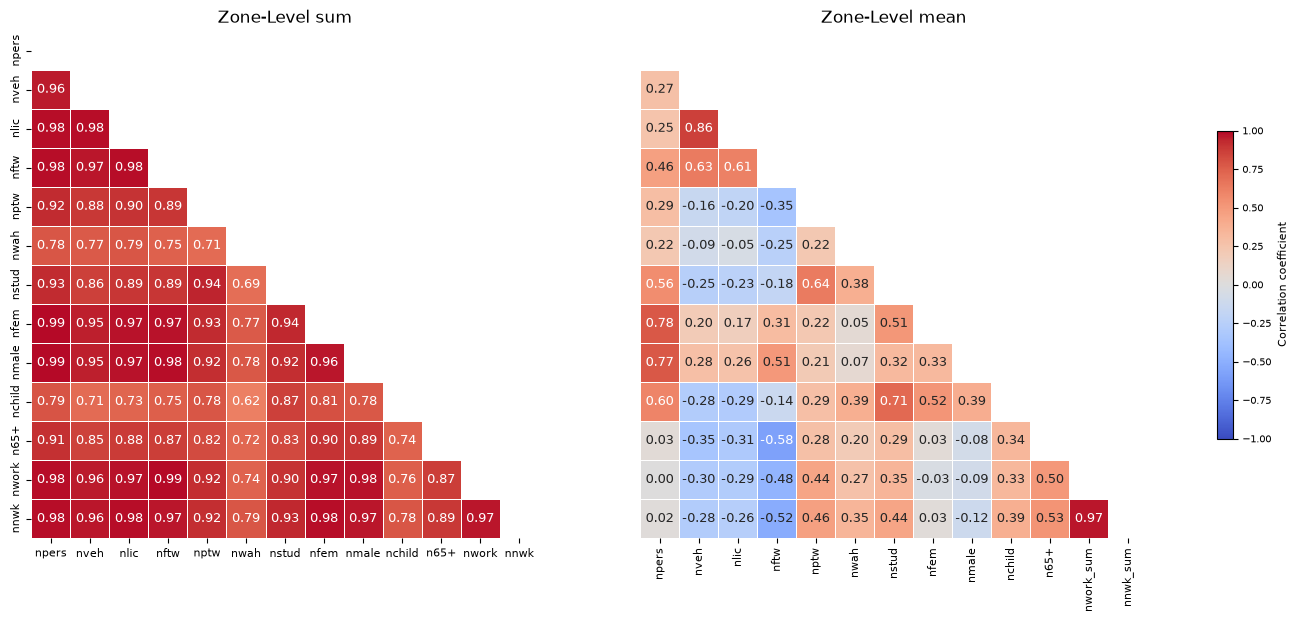

In [291]:
corr_zones_sum = zone_df_sum[numeric_cols].corr(method="spearman")
corr_house_mean = zone_df_mean[numeric_cols2].corr(method="spearman")

plot_correlations(corr_zones_sum,corr_house_mean, title_left="Zone-Level sum", title_right="Zone-Level mean")

----------

To begin the analysis, we first conduct a correlation analysis to better define the functions to be used and to anticipate potential collinearity issues. Regarding zonal data, the totals show strong correlations with most variables specifically """nftw", "npers", "nlic", "nfem", and "nmale". However, the potential explanatory variables appear to be highly correlated with one another, raising the risk of multicollinearity. For work-related trips ("nwork"), "nftw_sum" stands out as the most robust baseline predictor, showing the strongest correlation (0.99), a result that makes intuitive sense. For non-work trips, "npers_sum" shows a strong correlation; this is logical, given that household size is a key driver of non-work travel.

In addition to aggregate totals, we also examined average values, which provide valuable insights. However, many of these averages show relatively weak correlations with total trip counts—our target variable. For work-related trips, "nptw_mean" and "nstud_mean" could serve as complementary variables. Meanwhile, "n65+_mean" shows a relatively high correlation, though its application in potential models requires further careful study.

Regarding non-work trips, "nptw_mean", "nstud_mean", "nchild_mean", and "n65+_mean" are reasonable candidates for further evaluation. In conclusion, using both aggregate totals and average values ​​appears highly beneficial for estimating trip generation in zonal models.

----------

#### 3.1.1 Model 1 "Baseline" Zonal-Work (nwork_sum ~ nftw_sum).

                             OLS Regression Results                            
Dep. Variable:               nwork_sum   R-squared:                       0.992
Model:                             OLS   Adj. R-squared:                  0.992
Method:                  Least Squares   F-statistic:                     5973.
Date:              dom., 20 sept. 2026   Prob (F-statistic):           3.46e-51
Time:                         12:36:28   Log-Likelihood:                -150.62
No. Observations:                   49   AIC:                             305.2
Df Residuals:                       47   BIC:                             309.0
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9950      1.009     -0.98

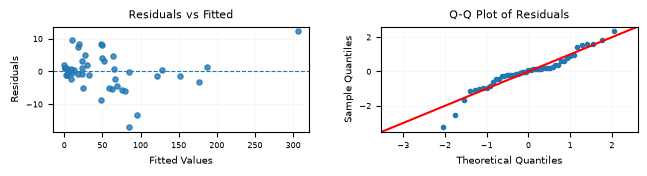

In [292]:
model = smf.ols(
    "nwork_sum ~ nftw_sum",
    data=zone_df
).fit()

print(model.summary())
show_anova(model)
plot_regression_diagnostics(model)

------------

For the initial zonal regression model, the variable number of full-time workers (*nftw*) was used; the adjusted $R^2$ value of 0.992 suggests a high-performing model. Furthermore, the explanatory variable's p-value is very low (0.00), indicating high statistical significance. The t-statistic of 77.286, specifically its high absolute value also confirms the variable's significance.

The model shows an extremely high goodness-of-fit. However, this result should be interpreted carefully because the aggregation of household data into zonal totals can produce very strong relationships driven by zone size. The positive sign of the variable aligns with expected behavior regarding the relationship between the number of workers and the volume of trips.

Additionally, the residual plot is observed to be random around zero, which shows that the errors do not appear to be related and the model appears to be well specified.

$$
\widehat{nwork\_sum}
=
-0.9950
+
1.0364\,nftw\_sum
$$

----------

#### 3.1.2 Model 2 "bivariate" Zonal-Work (nwork_sum ~ nftw_sum + nptw_sum)

Now we move on to a model with the following independent variable; we therefore select the one showing the highest ranking in relation to the number of daily work trips. Based on the correlation values, we select the "number of part-time workers" (nptw), given its correlation coefficient of 0.908

                             OLS Regression Results                            
Dep. Variable:               nwork_sum   R-squared:                       0.993
Model:                             OLS   Adj. R-squared:                  0.993
Method:                  Least Squares   F-statistic:                     3258.
Date:              dom., 20 sept. 2026   Prob (F-statistic):           2.83e-50
Time:                         10:54:16   Log-Likelihood:                -147.98
No. Observations:                   49   AIC:                             302.0
Df Residuals:                       46   BIC:                             307.6
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0170      0.967     -1.05

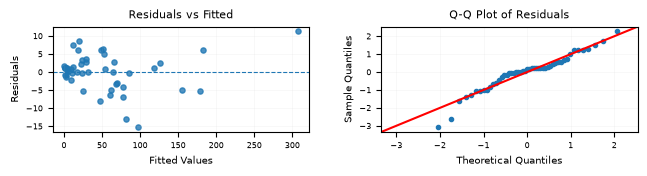

In [239]:
model2 = smf.ols(
    "nwork_sum ~ nftw_sum + nptw_sum",
    data=zone_df
).fit()

print(model2.summary())
show_anova(model2)
plot_regression_diagnostics(model2)

---------

In the following model, we observe an adjusted $R^2$ value of 0.993, indicating a marginal improvement over the previous model and reinforcing the conclusion that this is a high-performing model. Furthermore, an examination of the independent variables reveals that both variables have p-values below 0.05, indicating that they are statistically significant. Additionally, the coefficients for both variables are positive, which aligns with the expected behavior regarding the number of full-time and part-time workers.

The estimated regression model is:

$$
\widehat{nwork\_sum}
=
-1.0170
+
0.9727\,nftw\_sum
+
0.4617\,nptw\_sum
$$

----------

#### 3.1.3 Model 3 "Stepwise - Algorithm" Zonal-Work

-------

To achieve the objective of developing a better linear regression model, an automated stepwise selection method was employed. In this method, variables are introduced sequentially and using the Akaike Information Criterion (AIC). This is because the AIC balances the model's goodness of fit and complexity: the lower the AIC, the better the model among those being compared. Therefore, the model with the lowest AIC was selected as the best.

--------

In [330]:
# report: hide-output
X_candidates = ["nptw_mean","nstud_mean","nchild_mean","nveh_mean","nwah_mean","nftw_sum","nftw_sum","nveh_sum ","npers_sum ","nlic_sum ","nptw_sum ","nwah_sum ","nstud_sum "]

model_forward, selected_forward = stepwise_forward(
    data=zone_df,y="nwork_sum",X_candidates=X_candidates, criterion="aic")

Add nftw_sum     AIC = 305.243
Add nptw_sum     AIC = 301.967
Add nveh_sum     AIC = 299.483
Add nstud_sum    AIC = 296.739


In [294]:
print(model_forward.summary())
show_anova(model_forward)

                             OLS Regression Results                            
Dep. Variable:               nwork_sum   R-squared:                       0.994
Model:                             OLS   Adj. R-squared:                  0.994
Method:                  Least Squares   F-statistic:                     1883.
Date:              dom., 20 sept. 2026   Prob (F-statistic):           1.47e-48
Time:                         12:39:00   Log-Likelihood:                -143.37
No. Observations:                   49   AIC:                             296.7
Df Residuals:                       44   BIC:                             306.2
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1482      0.979      0.15

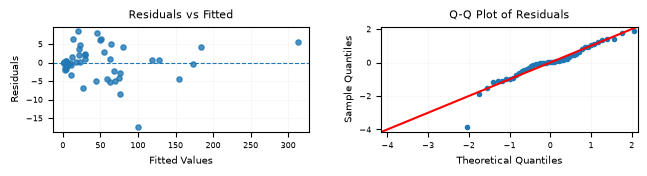

In [295]:
plot_regression_diagnostics(model_forward)

-----------

$$
\widehat{nwork\_sum} = 0.1482 + 1.0406\,nftw\_sum + 1.0925\,nptw\_sum- 0.1643\,nveh\_sum - 0.2469\,nstud\_sum
$$

As a result of applying the stepwise-AIC algorithm, four potential explanatory variables were identified for our model: nftw_sum, nptw_sum, nveh_sum, and nstud_sum. After testing all candidates, the value decreased to approximately 296.7. In this model, full-time and part-time workers show positive, statistically significant coefficients, which is consistent with work trip generation. However, the coefficients for the vehicle and student terms are negative and should be interpreted with caution due to aggregation and potential multicollinearity among zonal totals. Similarly, residual analysis suggests that the residuals do not fully follow a normal distribution (Omnibus, Skewness, Kurtosis); therefore, it is worth comparing this model with simpler ones.

---------

### 3.2. Household-based model for work-related trips

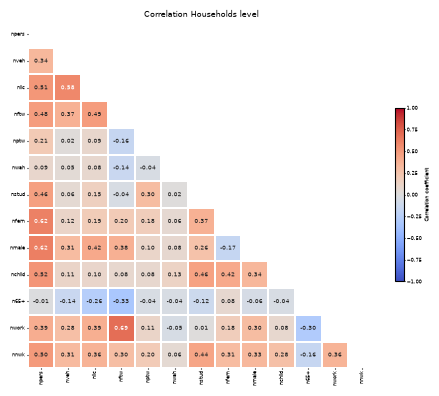

In [308]:
corr_households = df[numeric_cols].corr(method="spearman")

plot_correlation_1(corr_households, title="Correlation Households level", figsize=(5.2, 3.9))

-----------

Regarding households, the correlations are more distinct than in the zonal cases; consequently, it is easier to compare potential linear effects among the variables. For work-related trips, the number of full-time workers (*nftw*) remains the strongest predictor (~0.69), followed by the number of persons (*npers*) and the number of driver's licenses (*nlic*) (~0.39); finally, the number of vehicles (*nveh*) also shows significant values, though these are lower and should still be taken into account.

Regarding non-work trips, the *npers* variable shows the strongest relationship (~0.50), followed by *nstud* (~0.44), *nlic* (~0.36), and *nveh* (~0.31). The differences between these two categories align with expectations, as non-work trips appear to be more closely related to the total number of persons and household composition.

----------

#### 3.2.1 Model 4 "Baseline" Household-Work (nwork ~ nftw)

                             OLS Regression Results                            
Dep. Variable:                   nwork   R-squared:                       0.420
Model:                             OLS   Adj. R-squared:                  0.420
Method:                  Least Squares   F-statistic:                     1673.
Date:              dom., 20 sept. 2026   Prob (F-statistic):          1.58e-275
Time:                         16:12:16   Log-Likelihood:                -2666.2
No. Observations:                 2310   AIC:                             5336.
Df Residuals:                     2308   BIC:                             5348.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2149      0.026      8.22

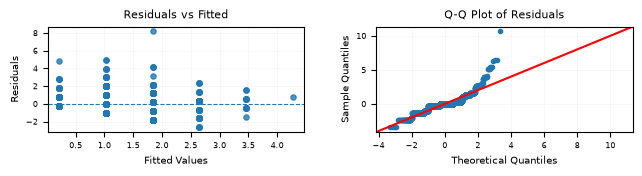

In [316]:
model_32 = smf.ols(
    "nwork ~ nftw",
    data=df
).fit()

print(model_32.summary())
show_anova(model_32)
plot_regression_diagnostics(model_32)

--------------

In this household model of work trips, it can be shown that the number of full-time workers (nftw) is highly related and statistically significant with work trips made on a daily basis. The coefficient of 0.81 is positive, consistent with the expected behavior. The model explains 42% of the variance in work trips ($R^2$ approx 0.42) that seems quite acceptable when dealing with disaggregated household data. But the model's residuals do not appear to follow a normal distribution; therefore, this simple model should be taken only as a good starting point.

--------

#### 3.2.2 Model 5 "Bivariate" Household-Work (nwork ~ nftw + nptw)

----------------

For this next model, another new variable was included to provide further information and better explain the variability within the model; consequently, the number of part-time workers (*nptw*) was incorporated.

                             OLS Regression Results                            
Dep. Variable:                   nwork   R-squared:                       0.469
Model:                             OLS   Adj. R-squared:                  0.468
Method:                  Least Squares   F-statistic:                     1017.
Date:              dom., 20 sept. 2026   Prob (F-statistic):          1.73e-317
Time:                         12:54:54   Log-Likelihood:                -2565.5
No. Observations:                 2310   AIC:                             5137.
Df Residuals:                     2307   BIC:                             5154.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0945      0.026      3.58

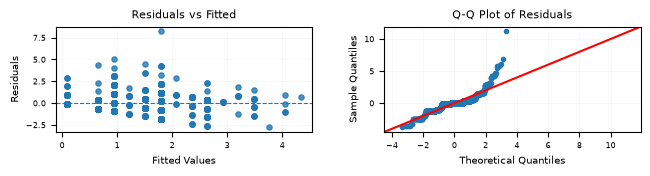

In [309]:
model_322 = smf.ols(
    "nwork ~ nftw + nptw",
    data=df
).fit()

print(model_322.summary())
show_anova(model_322)
plot_regression_diagnostics(model_322)

------------

The second model performs better than the base model because the inclusion of *nptw* enhances its explanatory power: the $R^2$ value increases from about 0.42 to 0.47. In both cases, *nftw* and *nptw* are statistically significant ($p<0.001$) and have positive values, which conforms to work-trip generation, where a high number of full-time and part-time workers are associated with a higher number of work trips. The *nftw* coefficient is about 0.85, and the *nptw* coefficient is about 0.56, indicating that part-time workers have a lower impact on work trips compared to full-time workers. However, residual diagnostics continue to show a strong deviation from normality.

............

#### 3.2.3 Model 6 "Stepwise Algorithm" Household-Work

In [299]:
X_candidates2 = ["nftw", "nlic", "npers", "nveh", "nptw", "nwah", "nstud", "nchild"]

model_forward_HH, selected_forward_HH = stepwise_forward(data=df,y="nwork",X_candidates=X_candidates2, criterion="aic")

Add nftw         AIC = 5336.340
Add nptw         AIC = 5136.969
Add nwah         AIC = 5121.263
Add nstud        AIC = 5117.573


                             OLS Regression Results                            
Dep. Variable:                   nwork   R-squared:                       0.474
Model:                             OLS   Adj. R-squared:                  0.473
Method:                  Least Squares   F-statistic:                     519.3
Date:              dom., 20 sept. 2026   Prob (F-statistic):          1.52e-319
Time:                         12:39:05   Log-Likelihood:                -2553.8
No. Observations:                 2310   AIC:                             5118.
Df Residuals:                     2305   BIC:                             5146.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0789      0.027      2.86

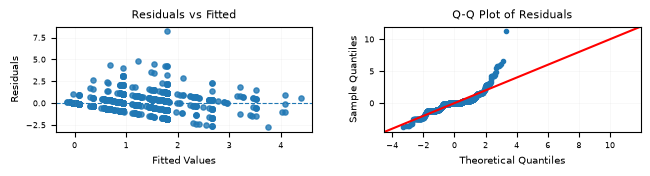

In [300]:
print(model_forward_HH.summary())
show_anova(model_forward_HH)
plot_regression_diagnostics(model_forward_HH)

------------

In this step-by-step model, there is a slight improvement in $R^2$ compared to the bivariate model, rising from approximately 0.469 to 0.474, and the algorithm has selected *nftw*, *nptw*, *nwah*, and *nstud* as the combination of variables yielding the minimum AIC value. All four variables are significant; *nftw* and *nptw* remain the strongest positive predictors of work trips. *nwah* is positively related to the outcome, while *nstud* shows a weakly negative coefficient. Thus, additional household characteristics provide a small improvement beyond employment status. However, the improvement is quite modest, and residual analysis still reveals a significant deviation from a normal distribution due to high skewness and kurtosis. Consequently, while this model offers a slight statistical improvement over the previous one, its adoption would be justified if it proves to be truly significant when compared to the bivariate model.

------------

## 3.3 Conclusions question 1

------------

In conclusion, regarding regression models for work-related travel, the most evident finding is the marked difference in $R^2$ values: zone-based models show R-squared values around 0.99, very close to 1; whereas household-aggregated models hover around 0.47. This indicates that zonal aggregation creates a stronger association between the explanatory variables and work trips, particularly regarding the number of full-time workers. However, this does not necessarily mean that zonal models provide a better explanation of travel behavior, as they are heavily influenced by zone size and the correlation between aggregated variables.

On the other hand, household-level models can be highly useful for capturing behavioral logic; in these models, variables such as the number of full-time workers (nftw) and part-time workers (nptw) emerge as highly significant predictors that largely drive trip forecasting. This result is directly interpretable: households with more working individuals generate more work trips, which aligns perfectly with expected behavior. It is important to note that a lower $R^2$ value does not imply a poor model; rather, this can occur because disaggregated data inherently contain much greater variability.

Regarding which models best capture behavior, both have advantages and disadvantages; however, the household-based model is more likely to capture the variability present across households, whereas the zonal model depends on the level of homogeneity within each zone.

For transport forecasting purposes, both models can be useful for forecasting, regardless of comparative goodness-of-fit values. However, I would prefer the household-based model when sufficient household data are available, because it provides a more behaviorally interpretable representation of trip generation. The zonal model remains useful when a simpler aggregated forecasting approach is required.



## **4. QUESTION 2**

-------

**Similarly develop a household-based model of daily non-work trip generation using linear regression. Compare your results with those obtained for the household-based work trip model with respect to issues such as explanatory variables used, parameters, statistical significance, and model goodness-of-fit. Discuss likely reasons for these differences.**

-------

### 4.1. Household-based model for non-work-related trips
-----------

For question number 2, the focus will be on non-work-related trips, using households as the unit of analysis. Thus, to better understand trip generation behavior, the variables most significant to non-work-related trip generation will be examined and selected.
The same methodology as in the previous question will be applied—selecting variables with the highest linear correlation with the explanatory variable while attempting to minimize the risk of multicollinearity—and the results will be compared against a stepwise algorithm.

#### 4.1.1 Model 7 "Base" Household  -Non-work (nnwk ~ npers)
-----------

For our baseline model, we will use the number of people in the household, since the previous correlation analysis shows that, preliminarily, non-work-related travel appears to have a marked linear relationship with this variable.

In [319]:
model3 = smf.ols(
    "nnwk ~ npers",
    data=df
).fit()

print(model3.summary())
show_anova(model3)


                             OLS Regression Results                            
Dep. Variable:                    nnwk   R-squared:                       0.296
Model:                             OLS   Adj. R-squared:                  0.296
Method:                  Least Squares   F-statistic:                     971.8
Date:              dom., 20 sept. 2026   Prob (F-statistic):          2.36e-178
Time:                         16:15:29   Log-Likelihood:                -4969.6
No. Observations:                 2310   AIC:                             9943.
Df Residuals:                     2308   BIC:                             9955.
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4433      0.084      5.26

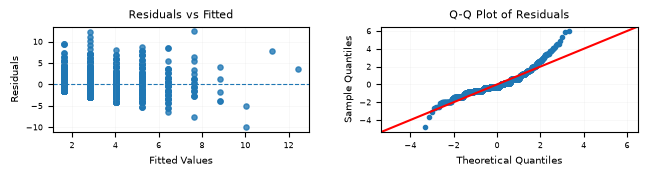

In [320]:
plot_regression_diagnostics(model3)

------------------

The household non-work trip model shows that the number of people in the household (npers) is a significant predictor of daily non-work trips. This means that there is a relationship between the number of people in the household and the number of trips made per day.  This is a very significant predictor, with a t-statistic of 31.17 that exceeds the critical values ​​of 1.64 and 1.96 and a p-value near zero. The model explains approximately 29.6% of the observed variation in non-work trips, this also indicates that a substantial part of the variation remains unexplained.

---------------

#### 4.1.2 Model 8 "Bivariate" Household  -Non-work

---------

As a next step, a two-variable model will be used; in this case, the number of vehicles will be selected. This is because it is a value with a correlation of 0.31; However, other variables, such as the composition of the people, could be related to the number of people or licenses, as well as the number of vehicles. Additionally, it may prove useful for the next exercise.

In [321]:
model4 = smf.ols(
    "nnwk ~ npers + nveh",
    data=df
).fit()

print(model4.summary())
show_anova(model4)

                             OLS Regression Results                            
Dep. Variable:                    nnwk   R-squared:                       0.318
Model:                             OLS   Adj. R-squared:                  0.317
Method:                  Least Squares   F-statistic:                     536.6
Date:              dom., 20 sept. 2026   Prob (F-statistic):          4.33e-192
Time:                         16:15:48   Log-Likelihood:                -4934.3
No. Observations:                 2310   AIC:                             9875.
Df Residuals:                     2307   BIC:                             9892.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2870      0.085      3.37

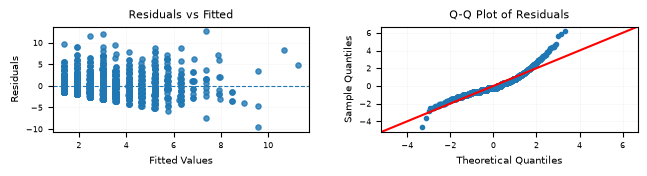

In [322]:
plot_regression_diagnostics(model4)

-----------

The bivariate non-work trip model is an improvement over the base model, incorporating both the number of vehicles (nveh) and the number of household members (npers). Both variables are statistically significant with p-values ​​close to zero, suggesting sufficient evidence of an association with non-work trip generation.

Regarding model fit, the current model yields an $R^2$ of approximately 0.318 and an adjusted $R^2$ of approximately 0.317, whereas the base model has an $R^2$ of 0.296. This indicates an improvement in model fit upon including nveh as a predictor. Furthermore, both variables are highly significant. However, the residuals are clearly not normally distributed; this is evident in the tails of the Q-Q plot and in statistics such as Prob(Omnibus).

---------

#### 4.1.3 Model 9 "Stepwise Algorithm" Household  -Non-work

---------

Once again, the stepwise algorithm will be used in this section to select a candidate combination of explanatory variables in an automated manner; the AIC statistic will again be used as the value to be minimized.

In [325]:
# report: hide-output
X_candidates3 = ["npers", "nveh", "nlic", "nstud", "nchild", "nftw", "nptw", "nwah"]

model_forward_NW, selected_forward_NW = stepwise_forward(data=df,y="nnwk",X_candidates=X_candidates3, criterion="aic")

Add npers        AIC = 9943.210
Add nstud        AIC = 9756.684
Add nveh         AIC = 9634.616
Add nlic         AIC = 9601.902
Add nftw         AIC = 9588.423
Add nwah         AIC = 9577.738
Add nptw         AIC = 9568.508


In [323]:
print(model_forward_NW.summary())

                             OLS Regression Results                            
Dep. Variable:                    nnwk   R-squared:                       0.405
Model:                             OLS   Adj. R-squared:                  0.403
Method:                  Least Squares   F-statistic:                     223.6
Date:              dom., 20 sept. 2026   Prob (F-statistic):          6.59e-254
Time:                         16:18:08   Log-Likelihood:                -4776.3
No. Observations:                 2310   AIC:                             9569.
Df Residuals:                     2302   BIC:                             9614.
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5409      0.086      6.27


ANOVA TABLE
           df   sum_sq  mean_sq        F     PR(>F)
npers       1 4208.263 4208.263 1145.880 3.314e-204
nstud       1  783.305  783.305  213.288  2.893e-46
nveh        1  481.684  481.684  131.159  1.422e-29
nlic        1  130.207  130.207   35.454  3.011e-09
nftw        1   57.433   57.433   15.639  7.899e-05
nwah        1   46.778   46.778   12.737  3.658e-04
nptw        1   41.200   41.200   11.218  8.230e-04
Residual 2302 8454.133    3.673      NaN        NaN


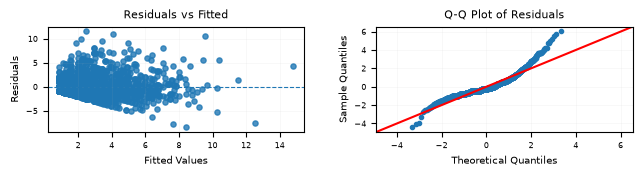

In [331]:
show_anova(model_forward_NW)
plot_regression_diagnostics(model_forward_NW)

<!-- ----------------

The model of non-working trips in households is certainly more refined than the former specifications. The algorithm identified npers, nstud, nveh, nlic, nftw, nwah, and nptw, decreasing AIC by almost 374 points, going from 9943 to 9569. All chosen predictors have positive coefficients and are statistically significant (p < 0.05). It means that each predictor is significant in its contribution to non-working trips after controlling for other predictors. Among the selected variables, npers and nstud appear to be particularly important predictors.

As regards goodness of fit, the regression has an  $R^2$ of roughly 0.405, compared to 0.318 for the two-variable model. As such, the stepwise model can explain significantly more of the variation in non-work trips within the household. Nevertheless, the results of the residual diagnostics indicate a substantial departure from normality, particularly in the upper tail of the Q-Q plot.


------------ -->

## 4.2 Conclusions question 2
------------

Regarding the comparison between work-related and non-work-related trips analyzed at the household level, it is worth noting that they exhibit distinct patterns, as evidenced by the identification of different significant variables and coefficients. Specifically, work-related trips are strongly influenced by the number of employed individuals; this was observed through the application of stepwise models, where this factor emerged as the predominant variable, while others proved far less significant.

In contrast, models for non-work-related trips appear less uniform; for instance, the stepwise algorithm identified variables such as the number of persons, students, vehicles, licenses, full-time workers, workers at home, and part-time workers. This suggests that a wider range of factors, such as household composition and vehicle ownership, among others, come into play for these trips. This aligns well with the notion that non-work trips can encompass a variety of activities beyond just commuting to work.

Regarding model goodness-of-fit, work-related trips achieved an R² of approximately 0.474, whereas non-work trips reached an R² of approximately 0.405. This difference in explanatory power may stem from several factors: work-related trips tend to be highly structured and closely linked to the number of employed individuals, whereas non-work trips are more heterogeneous in terms of both the activities involved and the people undertaking them.

This exercise suggests that more structured trips, such as work trips, can be explained with fewer variables. Conversely, due to their heterogeneity, non-work trips appear to require a greater number of household-level variables to be effectively explained.

## *5. QUESTION 3*
--------

**Develop a cross-classification model of non-work trip generation using household size (i.e. number of persons in the household) and number of autos as the explanatory variables. Justify your selection of category definitions for each explanatory variable. Discuss your results in terms of their implications for how non-work trip generation varies with household size and number of autos, as well as in terms of the reliability of your results given the cell frequencies obtained. Also compare this model with the regression model developed in question 2. Which would you prefer to use for forecasting and why?**

----------

### 5.1 Model 9 Cross-classification model Non-work ("npers", "nveh")

In [304]:
# report: hide-cell
df_new = df[["npers", "nveh", "nnwk"]].copy()

df_new[["npers", "nveh"]] = (
    df_new[["npers", "nveh"]]
    .astype("category")
)

In [305]:
agrupacion= df_new.groupby( ["npers", "nveh"])["nnwk"].agg(["sum","count", "mean", "std"]).round(3)
agrupacion.head(5)

sum  count   mean    std
npers nveh                          
1     0     924    678  1.363  1.299
      1     769    380  2.024  1.789
      2      42     19  2.211  1.619
      3      17      5  3.400  3.362
      4       4      1  4.000    NaN

---

Trip rate cross-classification model

--------------

In [306]:
# report: hide-cell
pivot_nnwk = df_new.pivot_table(index="npers",columns="nveh",values="nnwk",aggfunc="mean",observed=True).round()
pivot_nnwk

nveh,0,1,2,3,4,5
npers,,,,,,
1,1.0,2.0,2.0,3.0,4.0,NaN
2,3.0,3.0,3.0,3.0,NaN,NaN
3,3.0,4.0,4.0,4.0,NaN,3.0
4,4.0,5.0,7.0,6.0,8.0,NaN
5,5.0,6.0,7.0,NaN,15.0,NaN
6,10.0,8.0,9.0,6.0,5.0,NaN
7,8.0,6.0,NaN,13.0,NaN,NaN
8,NaN,2.0,NaN,NaN,NaN,NaN
9,NaN,19.0,NaN,NaN,NaN,NaN


In [307]:
pivot_nnwk, npers_cut, nveh_cut = compact_pivot(
    data=df_new,
    row="npers",
    col="nveh",
    value="nnwk"
)

print("npers grouped from:", npers_cut)
print("nveh grouped from:", nveh_cut)
pivot_nnwk

npers grouped from: 6
nveh grouped from: 3


nveh,0,1,2,3 & more
npers,,,,
1,1.36,2.02,2.21,3.50
2,2.54,3.09,3.30,3.33
3,3.27,3.85,4.00,4.23
4,4.13,5.45,7.42,6.20
5,5.00,6.30,6.78,15.00
6 & more,10.40,8.00,8.60,7.50


---

Cross-classification table for trip counts by category

--------------

In [ ]:
# report: hide-code 
npers_group = df_new["npers"].apply(
    lambda x: f"{npers_cut} & more" if x >= npers_cut else str(int(x)))
nveh_group = df_new["nveh"].apply(
    lambda x: f"{nveh_cut} & more" if x >= nveh_cut else str(int(x)))
cell_frequency = pd.crosstab( npers_group, nveh_group)

cell_frequency = cell_frequency.reindex(
    index=["1", "2", "3", "4", "5", "6 & more"],
    columns=["0", "1", "2", "3 & more"],
    fill_value=0)

cell_frequency.index.name = "npers"
cell_frequency.columns.name = "nveh"

cell_frequency

nveh,0,1,2,3 & more
npers,,,,
1,678,380,19,6
2,272,376,115,3
3,78,113,36,13
4,31,82,24,5
5,17,23,9,1
6 & more,5,15,5,4


-----------------

The preceding cross-tabulation table shows that non-work trips are positively related to household size and vehicle ownership. Household size appears to have the greatest effect on this, while within the same household size class, those with a higher number of vehicles tend to make more non-work trips. Some extreme trip rates appear in sparsely populated cells. For example, the rate of 15.0 trips for households with five persons and three or more vehicles is based on only one sampled household and should therefore be interpreted with caution.

In contrast to the household-level regression model, the cross-classification strategy offers a simple way to represent out-of-home trip generation and can account for non-linear variations across household types without assuming a specific functional form for such variations. However, the accuracy of the cross-classification approach depends heavily on the number of observations per cell. While the regression model utilizes the entire sample alongside other household attributes, the cross-classification approach may result in some cells containing a limited number of observations.

----------------------

### 5.2 Conclusions question 3
------------------

Cross-classification analysis reveals that non-work trip rates tend to increase with household size and, generally, with vehicle ownership. The table clearly illustrates these relationships without requiring a specific regression equation. However, some cells may exhibit very high or irregular rates; this can occur when there is insufficient data for a specific combination of characteristics, making data frequency crucial for the model's performance.

Bins for "6+ persons" and "3+ vehicles" were created because the initial counts showed pairs of cells with null or very low data values. Consequently, some extreme trip rates are based on a very small number of observations, which could lead to irregular rates. Thus, grouping cells at these points helps reduce sparse cells and obtain more representative trip rates for the model.

Furthermore, when comparing regression models with cross-classification models, the latter are far simpler to estimate and interpret, a major advantage, as they do not require specific equations. However, their main limitation is that their quality depends heavily on the amount of data available to estimate the necessary intervals and capture the study area's characteristics. Additionally, incorporating further variables or dimensions into cross-classification models is not straightforward.

Given the above, I would prefer to use the household regression model for forecasting exercises. This is primarily because it allows for the inclusion of other variables and the study of their interrelationships regarding trip generation, as well as enabling estimates for intervals that might not be available in the cross-classification model. Nevertheless, the cross-classification model remains highly useful for interpreting patterns between two variables and serves as an excellent tool for data interpretation; however, regression models appear more robust for estimating future values.